# 2026-05-01 Hn/baseline EDA

`preprocess/data/processed/H{n}/baseline`에 추가된 H6~H24 horizon별 train/valid/test 데이터셋을 비교하고, 선택한 horizon의 결측/이상치/라벨/상관관계를 확인하는 EDA 노트북입니다.

- 생성일: `2026-05-01`
- 기본 분석 대상: `H6/baseline`
- 비교 대상: `H6, H8, H10, H12, H14, H16, H18, H20, H22, H24`


## 1. 설정 & 데이터 로드


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

# 실행 위치가 notebooks/, 프로젝트 루트, 또는 다른 하위 디렉터리여도 프로젝트 루트를 찾는다.
def find_project_root(start):
    start = Path(start).resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / "src").exists() and (candidate / "preprocess").exists():
            return candidate
    raise FileNotFoundError("프로젝트 루트를 찾지 못했습니다. kw0ss_project 안에서 Jupyter를 실행해 주세요.")

PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis.utils import (
    analyze_single_feature,
    build_outlier_decision_table,
    classify_columns,
    compare_group_stats_by_label,
    get_high_corr_pairs,
    high_missing_columns,
    missing_summary,
    plot_boxplot_by_label,
    plot_correlation_heatmap,
    plot_histogram,
    plot_missing_heatmap,
    render_outlier_html,
    summarize_dataframe,
)

KOREAN_FONT = "Apple SD Gothic Neo"
sns.set_theme(
    style="whitegrid",
    rc={
        "font.family": KOREAN_FONT,
        "font.sans-serif": [KOREAN_FONT],
        "axes.unicode_minus": False,
    },
)
plt.rcParams["font.family"] = KOREAN_FONT
plt.rcParams["font.sans-serif"] = [KOREAN_FONT]
plt.rcParams["axes.unicode_minus"] = False

DATA_ROOT = PROJECT_ROOT / "preprocess" / "data" / "processed"
HORIZONS = [6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
SPLITS = ["train", "valid", "test"]
SELECTED_H = 6
EXPERIMENT = "baseline"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"DATA_ROOT exists = {DATA_ROOT.exists()} ({DATA_ROOT})")


PROJECT_ROOT = /Users/hann/Project/kwoss/kw0ss_project
DATA_ROOT exists = True (/Users/hann/Project/kwoss/kw0ss_project/preprocess/data/processed)


In [2]:
def load_baseline_horizon(horizon):
    base_dir = DATA_ROOT / f"H{horizon}" / EXPERIMENT
    if not base_dir.exists():
        raise FileNotFoundError(f"baseline directory not found: {base_dir}")

    print(f"Loading H{horizon}/{EXPERIMENT} ...", flush=True)
    splits = {}
    for split in SPLITS:
        csv_path = base_dir / f"{split}.csv"
        print(f"  - {split}: {csv_path.name}", flush=True)
        splits[split] = pd.read_csv(csv_path, dtype={"stock_code": str})

    with open(base_dir / "meta.json", encoding="utf-8") as f:
        meta = json.load(f)
    return splits, meta

def load_baseline_meta(horizon):
    meta_path = DATA_ROOT / f"H{horizon}" / EXPERIMENT / "meta.json"
    with open(meta_path, encoding="utf-8") as f:
        return json.load(f)

# 처음에는 meta 전체 + 선택한 H만 로드한다. 전체 CSV는 뒤쪽 비교 셀에서 필요할 때 로드한다.
all_meta = {horizon: load_baseline_meta(horizon) for horizon in HORIZONS}
all_data = {}
all_data[SELECTED_H], _ = load_baseline_horizon(SELECTED_H)

def get_horizon_data(horizon):
    if horizon not in all_data:
        all_data[horizon], _ = load_baseline_horizon(horizon)
    return all_data[horizon]

print(f"Loaded metadata horizons: {list(all_meta)}")
print(f"Loaded data horizons: {list(all_data)}")
print(f"Selected horizon: H{SELECTED_H}/{EXPERIMENT}")
all_data[SELECTED_H]["train"].head()


Loading H6/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loaded metadata horizons: [6, 8, 10, 12, 14, 16, 18, 20, 22, 24]
Loaded data horizons: [6]
Selected horizon: H6/baseline


,stock_code,year,quarter,gics_sector,총자산증가율,유동자산증가율,매출액순이익률,매출총이익률,자기자본순이익률,매출채권회전율,...,매출액증가율,순이익증가율,영업이익증가율,credit_spread,kosdaq_return,gdp_growth_yoy,usdkrw_chg,vix_avg,cpi_yoy,label
0,000250,2015,ANNUAL,Health Care,6.823177,5.069563,13.534885,54.527317,11.583135,4.079641,...,9.417163,-3.719703,-1.029770,0.3758,0.5704,3.6,-1.8836,17.0333,0.9205,0
1,000250,2016,ANNUAL,Health Care,11.317289,17.845810,10.594630,53.655640,9.130630,3.850976,...,11.593392,-12.648630,17.316005,0.4344,-7.3061,2.8,10.2344,14.0979,1.4514,0
2,000250,2016,H1,Health Care,5.075305,5.007422,15.156818,53.451031,3.421313,1.087265,...,11.593392,-12.648630,17.316005,0.4607,-1.9306,3.9,0.9710,15.6759,0.8406,0
3,000250,2016,Q1,Health Care,1.922305,2.283415,13.871178,55.017883,3.030012,1.041355,...,11.593392,-12.648630,17.316005,0.4736,0.8837,3.0,-1.5785,20.4862,0.8593,0
4,000250,2016,Q3,Health Care,8.159723,9.332047,14.447036,54.245709,3.178143,1.042621,...,11.593392,-12.648630,17.316005,0.4111,0.9065,3.0,-5.8728,13.2339,0.7351,0


## 2. Horizon 메타 비교

각 horizon의 split 크기, 양성 라벨 수, 불균형 비율을 먼저 비교합니다.


In [3]:
meta_rows = []
for horizon, meta in all_meta.items():
    meta_rows.append({
        "horizon": f"H{horizon}",
        "train_rows": meta.get("train_rows"),
        "valid_rows": meta.get("valid_rows"),
        "test_rows": meta.get("test_rows"),
        "train_pos": meta.get("train_pos"),
        "valid_pos": meta.get("valid_pos"),
        "test_pos": meta.get("test_pos"),
        "train_pos_rate_pct": round(meta.get("train_pos", 0) / max(meta.get("train_rows", 1), 1) * 100, 3),
        "valid_pos_rate_pct": round(meta.get("valid_pos", 0) / max(meta.get("valid_rows", 1), 1) * 100, 3),
        "test_pos_rate_pct": round(meta.get("test_pos", 0) / max(meta.get("test_rows", 1), 1) * 100, 3),
        "imbalance_ratio": meta.get("imbalance_ratio"),
        "winsorize": meta.get("winsorize"),
        "robust_scale": meta.get("robust_scale"),
    })

meta_df = pd.DataFrame(meta_rows)
meta_df


,horizon,train_rows,valid_rows,test_rows,train_pos,valid_pos,test_pos,train_pos_rate_pct,valid_pos_rate_pct,test_pos_rate_pct,imbalance_ratio,winsorize,robust_scale
0,H6,34142,5050,5311,123,11,20,0.360,0.218,0.377,276.6,False,False
1,H8,32746,5050,5311,167,15,27,0.510,0.297,0.508,195.1,False,False
2,H10,31360,5050,5311,210,21,36,0.670,0.416,0.678,148.3,False,False
3,H12,31360,5050,5311,250,27,51,0.797,0.535,0.960,124.4,False,False
4,H14,29986,5050,5311,284,34,60,0.947,0.673,1.130,104.6,False,False
5,H16,29986,5050,3955,333,43,54,1.111,0.851,1.365,89.0,False,False
6,H18,29986,5050,3955,374,54,61,1.247,1.069,1.542,79.2,False,False
7,H20,29986,5050,2623,421,62,46,1.404,1.228,1.754,70.2,False,False
8,H22,29986,5050,1307,473,72,27,1.577,1.426,2.066,62.4,False,False
9,H24,29986,5050,1307,516,87,28,1.721,1.723,2.142,57.1,False,False


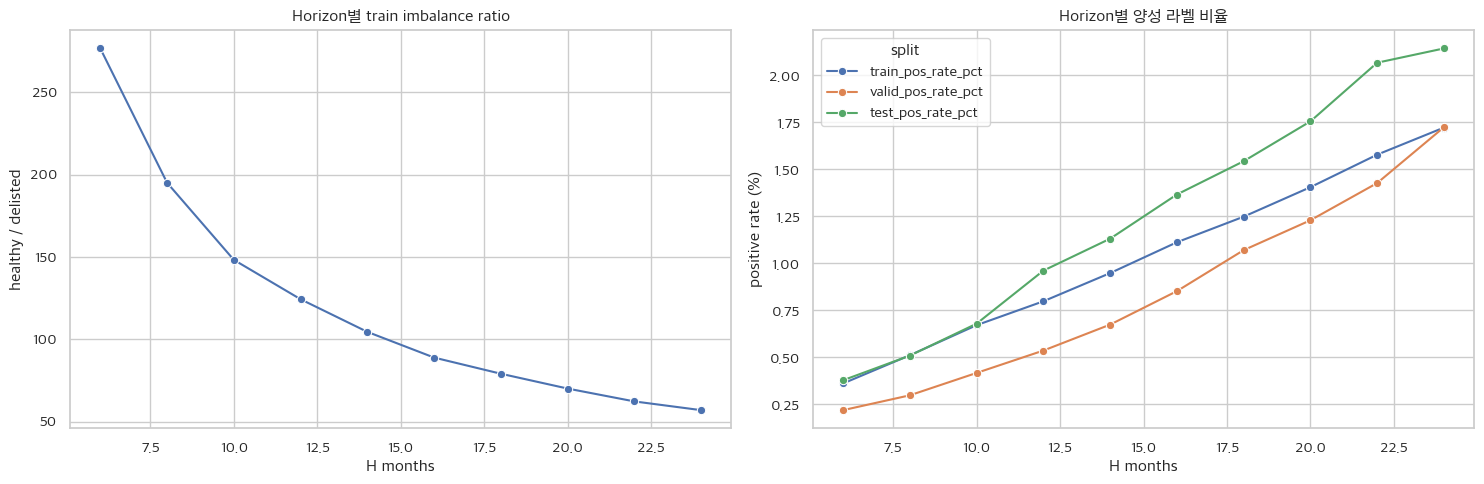

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

meta_plot = meta_df.assign(h_num=meta_df["horizon"].str.replace("H", "", regex=False).astype(int))

sns.lineplot(data=meta_plot, x="h_num", y="imbalance_ratio", marker="o", ax=axes[0])
axes[0].set_title("Horizon별 train imbalance ratio")
axes[0].set_xlabel("H months")
axes[0].set_ylabel("healthy / delisted")

rate_cols = ["train_pos_rate_pct", "valid_pos_rate_pct", "test_pos_rate_pct"]
rate_long = meta_plot.melt(id_vars=["h_num"], value_vars=rate_cols, var_name="split", value_name="positive_rate_pct")
sns.lineplot(data=rate_long, x="h_num", y="positive_rate_pct", hue="split", marker="o", ax=axes[1])
axes[1].set_title("Horizon별 양성 라벨 비율")
axes[1].set_xlabel("H months")
axes[1].set_ylabel("positive rate (%)")

plt.tight_layout()
plt.show()


## 3. 선택 Horizon 데이터 결합

`SELECTED_H` 값을 바꾸면 같은 분석을 다른 Hn/baseline 데이터에 적용할 수 있습니다.


In [5]:
splits = all_data[SELECTED_H]
df = pd.concat(
    [split_df.assign(split=split_name) for split_name, split_df in splits.items()],
    ignore_index=True,
)
cols = classify_columns(df.drop(columns=["split"]))

print(f"H{SELECTED_H}/{EXPERIMENT} shape: {df.shape}")
for split_name, split_df in splits.items():
    pos = int(split_df["label"].sum())
    print(f"{split_name:>5}: {len(split_df):,} rows, pos={pos:,}, pos_rate={pos / len(split_df):.4%}")

df.head()


H6/baseline shape: (44503, 42)
train: 34,142 rows, pos=123, pos_rate=0.3603%
valid: 5,050 rows, pos=11, pos_rate=0.2178%
 test: 5,311 rows, pos=20, pos_rate=0.3766%


,stock_code,year,quarter,gics_sector,총자산증가율,유동자산증가율,매출액순이익률,매출총이익률,자기자본순이익률,매출채권회전율,...,순이익증가율,영업이익증가율,credit_spread,kosdaq_return,gdp_growth_yoy,usdkrw_chg,vix_avg,cpi_yoy,label,split
0,000250,2015,ANNUAL,Health Care,6.823177,5.069563,13.534885,54.527317,11.583135,4.079641,...,-3.719703,-1.029770,0.3758,0.5704,3.6,-1.8836,17.0333,0.9205,0,train
1,000250,2016,ANNUAL,Health Care,11.317289,17.845810,10.594630,53.655640,9.130630,3.850976,...,-12.648630,17.316005,0.4344,-7.3061,2.8,10.2344,14.0979,1.4514,0,train
2,000250,2016,H1,Health Care,5.075305,5.007422,15.156818,53.451031,3.421313,1.087265,...,-12.648630,17.316005,0.4607,-1.9306,3.9,0.9710,15.6759,0.8406,0,train
3,000250,2016,Q1,Health Care,1.922305,2.283415,13.871178,55.017883,3.030012,1.041355,...,-12.648630,17.316005,0.4736,0.8837,3.0,-1.5785,20.4862,0.8593,0,train
4,000250,2016,Q3,Health Care,8.159723,9.332047,14.447036,54.245709,3.178143,1.042621,...,-12.648630,17.316005,0.4111,0.9065,3.0,-5.8728,13.2339,0.7351,0,train


## 4. 컬럼 분류 & 기본 통계


In [6]:
for group, col_list in cols.items():
    print(f"\n[{group}] ({len(col_list)}개)")
    print(col_list)



[meta] (5개)
['stock_code', 'year', 'quarter', 'gics_sector', 'label']

[ratio] (28개)
['총자산증가율', '유동자산증가율', '매출액순이익률', '매출총이익률', '자기자본순이익률', '매출채권회전율', '재고자산회전율', '총자본회전율', '유형자산회전율', '매출원가율', '부채비율', '유동비율', '자기자본비율', '당좌비율', '비유동자산장기적합률', '순운전자본비율', '차입금의존도', '현금비율', '무형자산상각비', '유형자산상각비', '감가상각비', '총자본영업이익률', '총자본순이익률', '유보액/납입자본비율', '총자본투자효율', '매출액증가율', '순이익증가율', '영업이익증가율']

[raw_value] (2개)
['유형자산', '무형자산']

[macro] (6개)
['credit_spread', 'kosdaq_return', 'gdp_growth_yoy', 'usdkrw_chg', 'vix_avg', 'cpi_yoy']


In [7]:
summarize_dataframe(df.drop(columns=["split"]))


,dtype,non_null,null_count,null_pct,unique,sample
stock_code,str,44503,0,0.0,1522,000250
year,int64,44503,0,0.0,11,2015
quarter,str,44503,0,0.0,4,ANNUAL
gics_sector,str,44503,0,0.0,11,Health Care
총자산증가율,float64,44503,0,0.0,41790,6.823177
유동자산증가율,float64,44503,0,0.0,42312,5.069563
매출액순이익률,float64,44503,0,0.0,42772,13.534885
매출총이익률,float64,44503,0,0.0,40854,54.527317
자기자본순이익률,float64,44503,0,0.0,43527,11.583135
매출채권회전율,float64,44503,0,0.0,43792,4.079641


In [8]:
df[cols["ratio"] + cols["raw_value"] + cols["macro"]].describe().T


,count,mean,std,min,25%,50%,75%,max
총자산증가율,44503.0,6.151861e+00,1.728871e+01,-4.358912e+01,-2.489968e+00,2.630417e+00,1.096890e+01,5.276120e+01
유동자산증가율,44503.0,6.805616e+00,2.752924e+01,-7.590967e+01,-7.419064e+00,2.248759e+00,1.520290e+01,8.505491e+01
매출액순이익률,44503.0,-1.599314e+01,7.885835e+01,-5.000000e+02,-8.515420e+00,2.041747e+00,9.175172e+00,1.000000e+02
매출총이익률,44503.0,2.474137e+01,2.542867e+01,-3.000000e+02,1.222277e+01,2.151642e+01,3.574179e+01,1.000000e+02
자기자본순이익률,44503.0,-3.173330e+00,3.066985e+01,-5.000000e+02,-2.548104e+00,8.340925e-01,3.468459e+00,1.000000e+02
매출채권회전율,44503.0,4.231048e+00,1.285312e+01,0.000000e+00,1.131272e+00,1.820980e+00,3.777878e+00,2.000000e+02
재고자산회전율,44503.0,9.842615e+00,3.166453e+01,0.000000e+00,8.243471e-01,1.648274e+00,4.838740e+00,2.000000e+02
총자본회전율,44503.0,3.208957e-01,3.655374e-01,0.000000e+00,1.122734e-01,1.965713e-01,3.723333e-01,9.052073e+00
유형자산회전율,44503.0,3.208957e-01,3.655374e-01,0.000000e+00,1.122734e-01,1.965713e-01,3.723333e-01,9.052073e+00
매출원가율,44503.0,7.638782e+01,2.572012e+01,0.000000e+00,6.501587e+01,7.866883e+01,8.798619e+01,3.000000e+02


## 5. 결측 분석

전체 결측률과 split별 결측률을 함께 확인합니다.


In [9]:
missing_summary(df.drop(columns=["split"]))


,dtype,null_count,null_pct
stock_code,str,0,0.0
현금비율,float64,0,0.0
무형자산,float64,0,0.0
무형자산상각비,float64,0,0.0
유형자산상각비,float64,0,0.0
감가상각비,float64,0,0.0
총자본영업이익률,float64,0,0.0
총자본순이익률,float64,0,0.0
유보액/납입자본비율,float64,0,0.0
총자본투자효율,float64,0,0.0


In [10]:
missing_by_split = []
for split_name, split_df in splits.items():
    miss = split_df.isna().mean().rename("missing_rate").reset_index().rename(columns={"index": "column"})
    miss["split"] = split_name
    missing_by_split.append(miss)

missing_by_split_df = pd.concat(missing_by_split, ignore_index=True)
missing_pivot = missing_by_split_df.pivot(index="column", columns="split", values="missing_rate")
missing_pivot.assign(max_missing=missing_pivot.max(axis=1)).sort_values("max_missing", ascending=False).head(20)


split,test,train,valid,max_missing
column,,,,
cpi_yoy,0.0,0.0,0.0,0.0
비유동자산장기적합률,0.0,0.0,0.0,0.0
순이익증가율,0.0,0.0,0.0,0.0
영업이익증가율,0.0,0.0,0.0,0.0
유동비율,0.0,0.0,0.0,0.0
유동자산증가율,0.0,0.0,0.0,0.0
유보액/납입자본비율,0.0,0.0,0.0,0.0
유형자산,0.0,0.0,0.0,0.0
유형자산상각비,0.0,0.0,0.0,0.0


결측률 30% 이상 컬럼: []


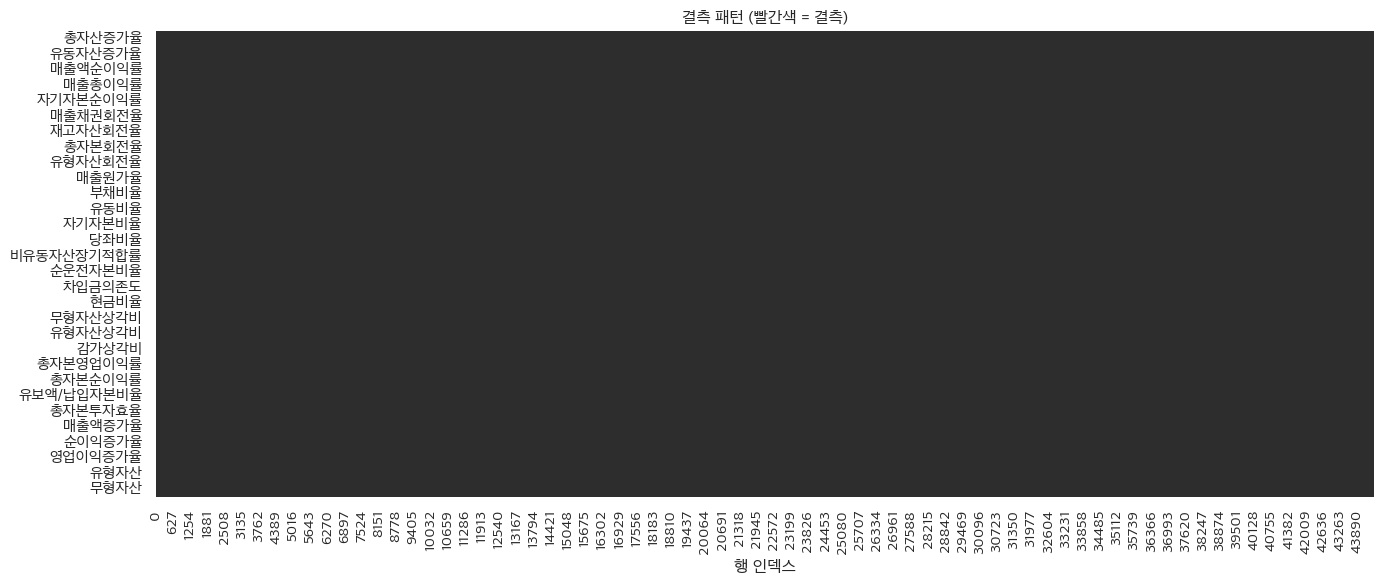

In [11]:
high_miss = high_missing_columns(df.drop(columns=["split"]), threshold=0.3)
print(f"결측률 30% 이상 컬럼: {high_miss}")
plot_missing_heatmap(df.drop(columns=["split"]))


## 6. 이상치 판정표

IQR 기반으로 ratio/raw/macro 컬럼의 이상치 후보를 확인합니다.


In [12]:
outlier_cols = cols["ratio"] + cols["raw_value"] + cols["macro"]
outlier_table = build_outlier_decision_table(df, numeric_cols=outlier_cols)
display(HTML(render_outlier_html(outlier_table, top_n=15)))

outlier_table[[
    "column", "count", "median", "iqr", "min", "max",
    "outlier_cnt_1_5", "outlier_ratio_1_5",
    "extreme_cnt_3_0", "extreme_ratio_3_0",
    "skew_signal", "distribution_note",
]].head(15)


컬럼,행 수,중앙값,IQR,최솟값,최댓값,이상치 수,이상치 비율,극단 수,극단 비율,왜도 신호,분포 방향
무형자산상각비,44503,0.00,5.32K,-79.93M,1232.81T,11105,24.9%,11076,24.9%,high,right-tailed
유형자산상각비,44503,0.00,91.03M,-13.70B,1532.47T,9969,22.4%,8981,20.2%,high,right-tailed
감가상각비,44503,0.00,146.35M,-12.59B,1649.19T,9796,22.0%,8622,19.4%,high,right-tailed
비유동자산장기적합률,44503,13.84,17.68,0.00,2.00K,7268,16.3%,5754,12.9%,high,right-tailed
영업이익증가율,44503,1.89,134.19,-518.84,532.85,7144,16.1%,4218,9.5%,low,symmetric or near-symmetric
순이익증가율,44503,0.73,165.08,-625.27,641.90,7051,15.8%,4435,10.0%,low,symmetric or near-symmetric
자기자본순이익률,44503,0.83,6.02,-500.00,100.00,6867,15.4%,3645,8.2%,moderate,left-tailed
매출액순이익률,44503,2.04,17.69,-500.00,100.00,6659,15.0%,4237,9.5%,high,left-tailed
총자본순이익률,44503,0.48,3.62,-500.00,100.00,6358,14.3%,3100,7.0%,moderate,left-tailed
총자본투자효율,44503,0.01,0.04,-79.03,2.89,6356,14.3%,3097,7.0%,moderate,left-tailed


,column,count,median,iqr,min,max,outlier_cnt_1_5,outlier_ratio_1_5,extreme_cnt_3_0,extreme_ratio_3_0,skew_signal,distribution_note
0,무형자산상각비,44503,0.000000e+00,5.316500e+03,-7.992660e+07,1.232815e+15,11105,0.2495,11076,0.2489,high,right-tailed
1,유형자산상각비,44503,0.000000e+00,9.103186e+07,-1.369827e+10,1.532466e+15,9969,0.2240,8981,0.2018,high,right-tailed
2,감가상각비,44503,0.000000e+00,1.463544e+08,-1.259410e+10,1.649187e+15,9796,0.2201,8622,0.1937,high,right-tailed
3,비유동자산장기적합률,44503,1.384030e+01,1.767530e+01,0.000000e+00,2.000000e+03,7268,0.1633,5754,0.1293,high,right-tailed
4,영업이익증가율,44503,1.894300e+00,1.341899e+02,-5.188420e+02,5.328543e+02,7144,0.1605,4218,0.0948,low,symmetric or near-symmetric
5,순이익증가율,44503,7.287000e-01,1.650812e+02,-6.252725e+02,6.418979e+02,7051,0.1584,4435,0.0997,low,symmetric or near-symmetric
6,자기자본순이익률,44503,8.341000e-01,6.016600e+00,-5.000000e+02,1.000000e+02,6867,0.1543,3645,0.0819,moderate,left-tailed
7,매출액순이익률,44503,2.041700e+00,1.769060e+01,-5.000000e+02,1.000000e+02,6659,0.1496,4237,0.0952,high,left-tailed
8,총자본순이익률,44503,4.849000e-01,3.615000e+00,-5.000000e+02,1.000000e+02,6358,0.1429,3100,0.0697,moderate,left-tailed
9,총자본투자효율,44503,5.000000e-03,3.610000e-02,-7.903300e+01,2.891200e+00,6356,0.1428,3097,0.0696,moderate,left-tailed


## 7. 라벨 분포


In [13]:
label_by_split = df.groupby("split")["label"].value_counts().unstack(fill_value=0)
label_by_split["positive_rate"] = label_by_split.get(1, 0) / label_by_split.sum(axis=1)
label_by_split


label,0,1,positive_rate
split,,,
test,5291,20,0.003766
train,34019,123,0.003603
valid,5039,11,0.002178


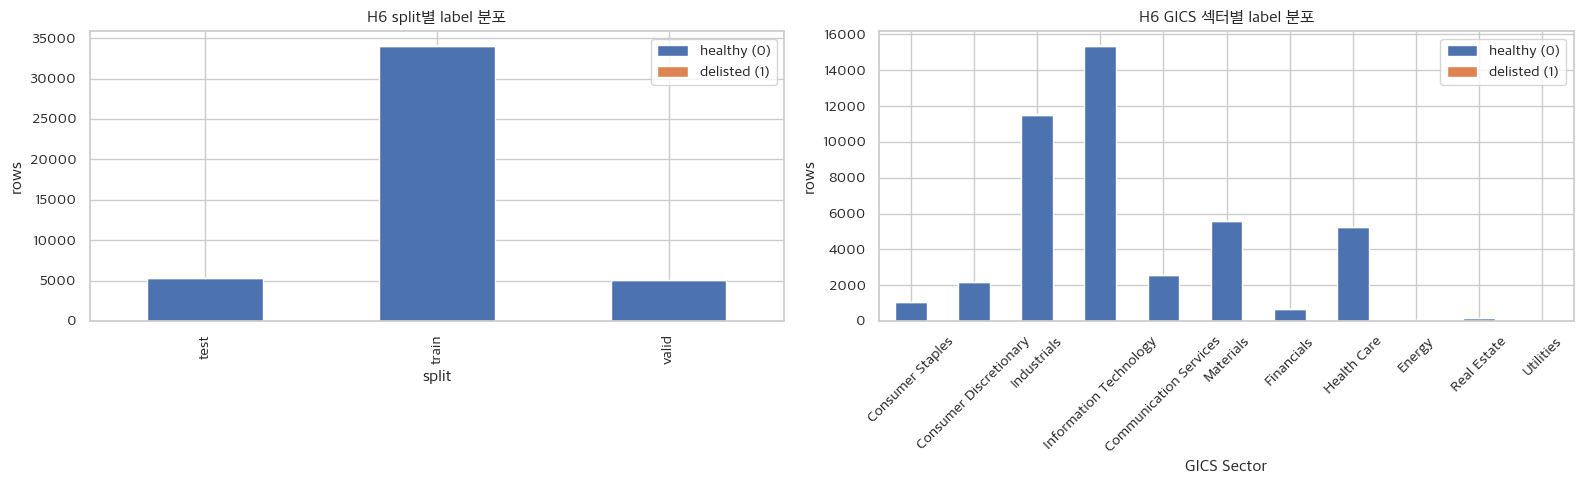

label,0,1,delisted_ratio
gics_sector,,,
Consumer Staples,1043,11,0.010436
Consumer Discretionary,2149,11,0.005093
Industrials,11478,55,0.004769
Information Technology,15352,51,0.003311
Communication Services,2587,6,0.002314
Materials,5575,12,0.002148
Financials,670,1,0.001490
Health Care,5236,7,0.001335
Energy,80,0,0.000000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_by_split[[0, 1]].plot(kind="bar", stacked=True, ax=axes[0])
axes[0].set_title(f"H{SELECTED_H} split별 label 분포")
axes[0].set_xlabel("split")
axes[0].set_ylabel("rows")
axes[0].legend(["healthy (0)", "delisted (1)"])

sector_label = df.groupby("gics_sector")["label"].value_counts().unstack(fill_value=0)
sector_label["delisted_ratio"] = sector_label.get(1, 0) / sector_label.sum(axis=1)
sector_label.sort_values("delisted_ratio", ascending=False)[[0, 1]].plot(kind="bar", stacked=True, ax=axes[1])
axes[1].set_title(f"H{SELECTED_H} GICS 섹터별 label 분포")
axes[1].set_xlabel("GICS Sector")
axes[1].set_ylabel("rows")
axes[1].legend(["healthy (0)", "delisted (1)"])
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

sector_label.sort_values("delisted_ratio", ascending=False)


## 8. 단변량 분포

주요 재무비율/매크로 컬럼의 전체 분포와 label별 차이를 확인합니다.


In [15]:
TARGET_FEATURES = [
    "부채비율",
    "유동비율",
    "자기자본비율",
    "매출액순이익률",
    "자기자본순이익률",
    "총자본영업이익률",
    "총자본회전율",
    "차입금의존도",
    "매출총이익률",
    "현금비율",
    "credit_spread",
    "kosdaq_return",
]



  부채비율
  count: 44503
  mean: 117.40442877289442
  median: 87.37947888160528
  std: 149.6659586178992
  min: 0.0
  max: 2000.0
  q1: 35.83715826292435
  q3: 150.35441398494117
  iqr: 114.51725572201683
  skewness: 6.412047271912707
  kurtosis: 64.14579170397084


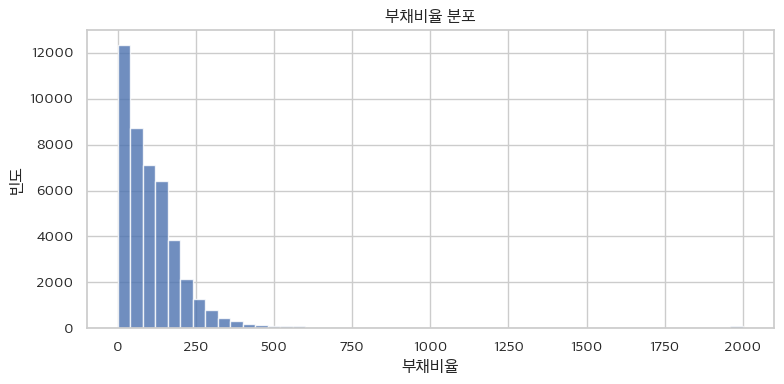

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


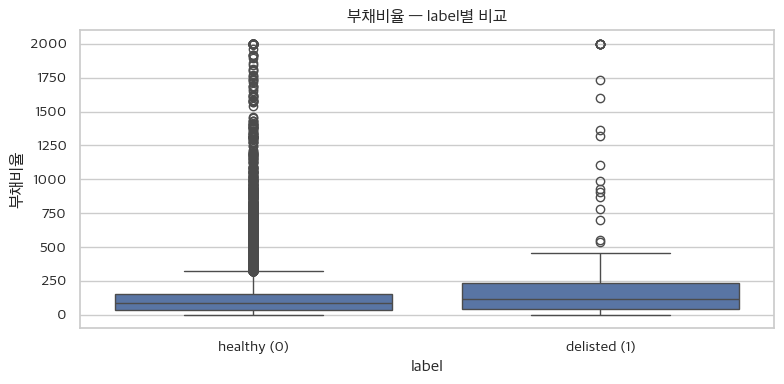


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,116.839253,87.236283,146.978426,0.0,2000.0,0.0
1,154,280.164020,116.861104,476.314273,0.0,2000.0,0.0



  유동비율
  count: 44503
  mean: 336.16940397973235
  median: 193.93118902675997
  std: 386.3899511321345
  min: 0.0
  max: 2000.0
  q1: 116.89074993593478
  q3: 374.19319844543463
  iqr: 257.30244850949987
  skewness: 2.6116143818047433
  kurtosis: 7.209795111913273


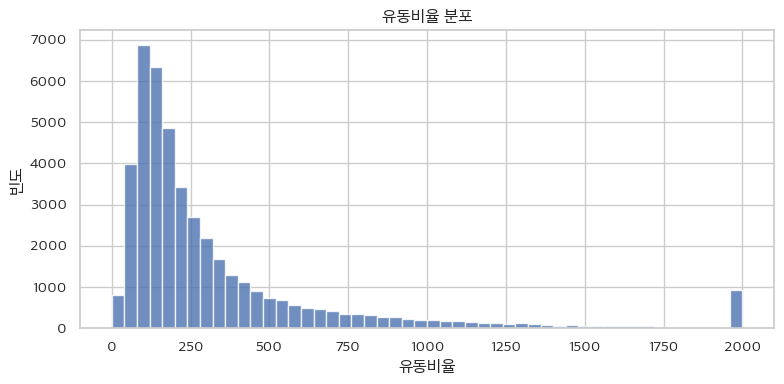

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


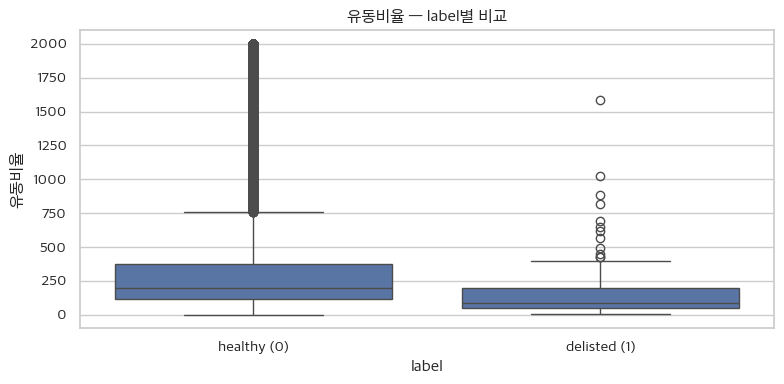


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,336.782901,194.295434,386.729846,0.00000,2000.000000,0.0
1,154,159.494231,89.684557,206.343376,5.44556,1587.835611,0.0



  자기자본비율
  count: 44503
  mean: 61.46713153245605
  median: 63.04098505511483
  std: 23.692083920521238
  min: -500.0
  max: 100.0
  q1: 46.78553526886883
  q3: 78.53868803735062
  iqr: 31.753152768481797
  skewness: -4.883767640708226
  kurtosis: 98.01147088987594


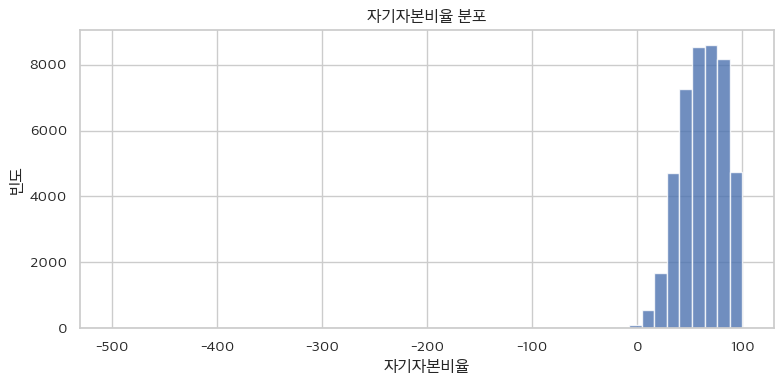

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


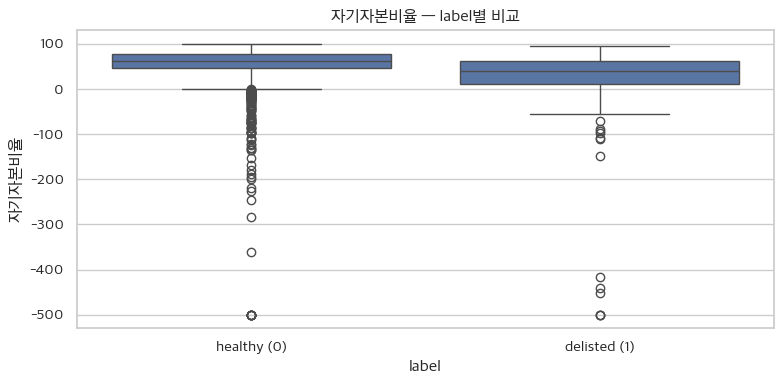


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,61.626525,63.102701,22.721369,-500.0,100.000,0.0
1,154,15.565023,40.770889,107.219840,-500.0,95.268,0.0



  매출액순이익률
  count: 44503
  mean: -15.99313617078599
  median: 2.041747335296059
  std: 78.85834894879734
  min: -500.0
  max: 100.0
  q1: -8.515419515472168
  q3: 9.175171980994449
  iqr: 17.690591496466617
  skewness: -4.563799985756563
  kurtosis: 23.115359007238638


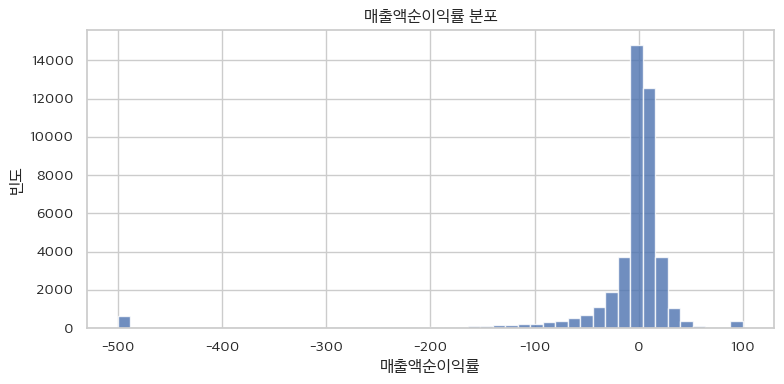

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


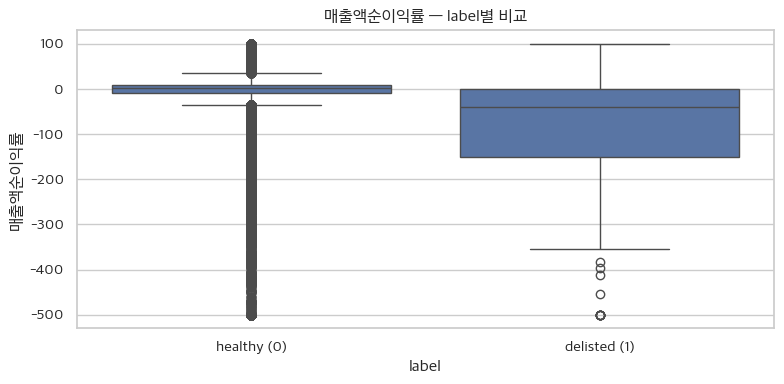


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,-15.720045,2.051493,78.412932,-500.0,100.0,0.0
1,154,-94.637995,-40.182460,142.537766,-500.0,100.0,0.0



  자기자본순이익률
  count: 44503
  mean: -3.173329909105321
  median: 0.8340925164346487
  std: 30.669851331951016
  min: -500.0
  max: 100.0
  q1: -2.5481042667638882
  q3: 3.4684589699823953
  iqr: 6.016563236746284
  skewness: -10.263921455166152
  kurtosis: 143.39041254479193


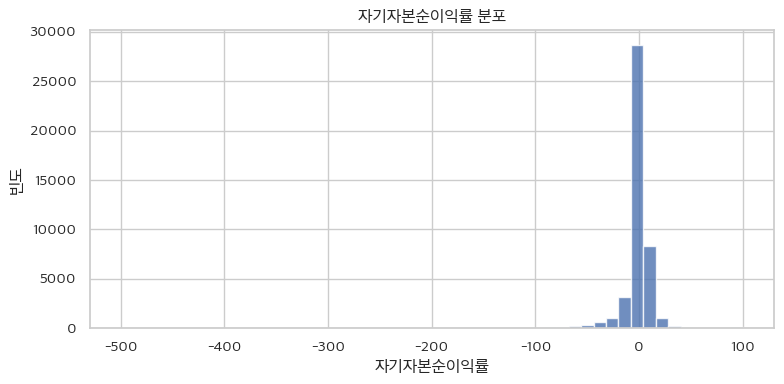

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


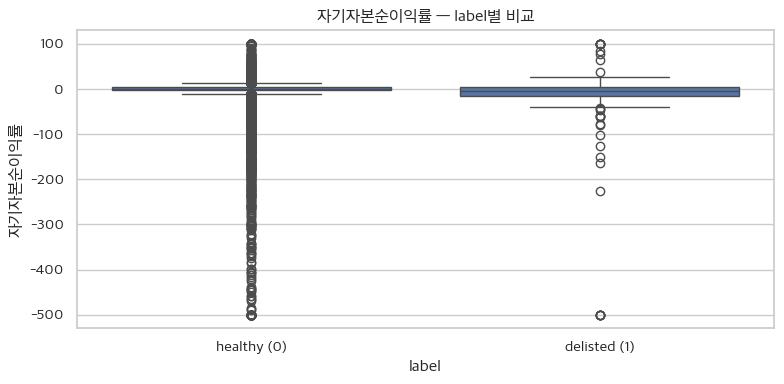


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,-3.099257,0.839474,30.069599,-500.0,100.0,0.0
1,154,-24.504980,-3.490943,105.143006,-500.0,100.0,0.0



  총자본영업이익률
  count: 44503
  mean: 0.1971497902536269
  median: 0.6103291325891196
  std: 7.985087475203057
  min: -500.0
  max: 64.5085745762734
  q1: -1.105053901762843
  q3: 2.2911086404226104
  iqr: 3.3961625421854533
  skewness: -16.937756543372757
  kurtosis: 848.6257129209275


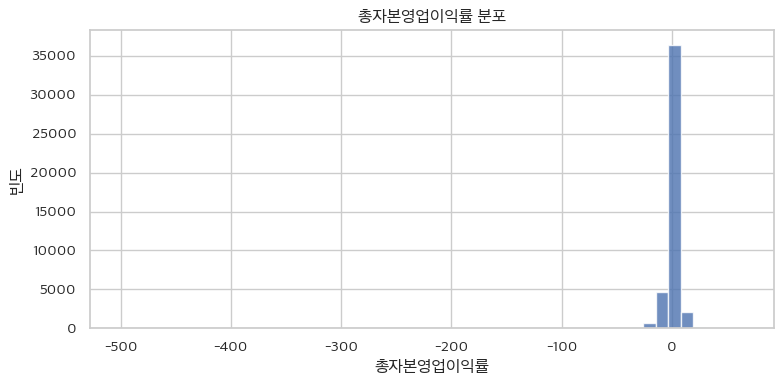

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


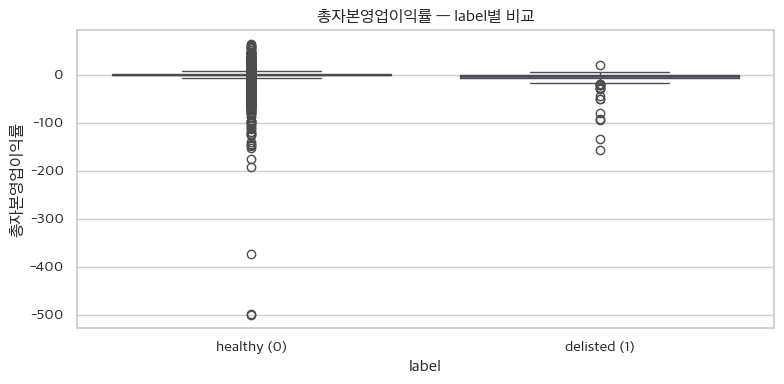


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,0.228775,0.619306,7.879772,-500.000000,64.508575,0.0
1,154,-8.910304,-2.882828,21.556789,-157.342678,20.834661,0.0



  총자본회전율
  count: 44503
  mean: 0.32089566358008076
  median: 0.196571324036905
  std: 0.36553738753114434
  min: 0.0
  max: 9.052073239367678
  q1: 0.11227338889112609
  q3: 0.3723333421268059
  iqr: 0.2600599532356798
  skewness: 3.32423482845871
  kurtosis: 22.294880803564922


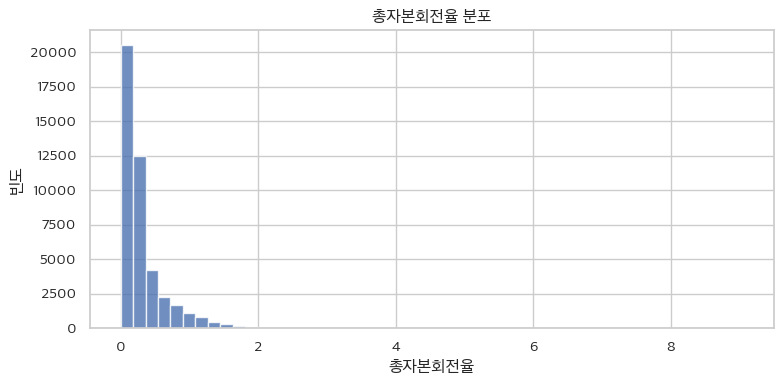

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


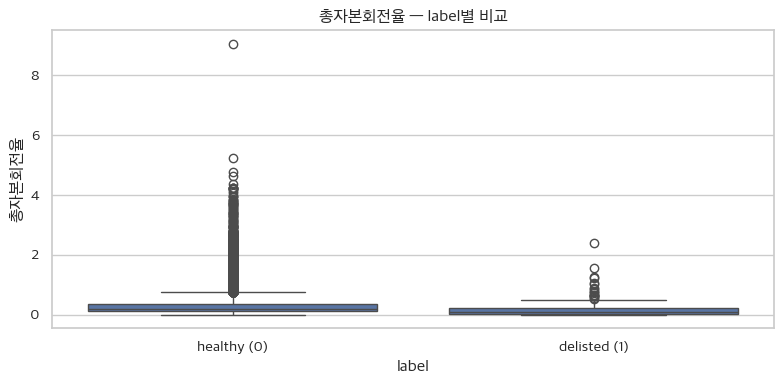


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,0.321278,0.196901,0.365621,0.0,9.052073,0.0
1,154,0.210738,0.099222,0.323296,0.0,2.408401,0.0



  차입금의존도
  count: 44503
  mean: 9.452011369550666
  median: 3.6959633049145424
  std: 12.389679668651338
  min: 0.0
  max: 100.0
  q1: 0.0
  q3: 15.784707861971457
  iqr: 15.784707861971457
  skewness: 1.5972202261386772
  kurtosis: 3.042015503522552


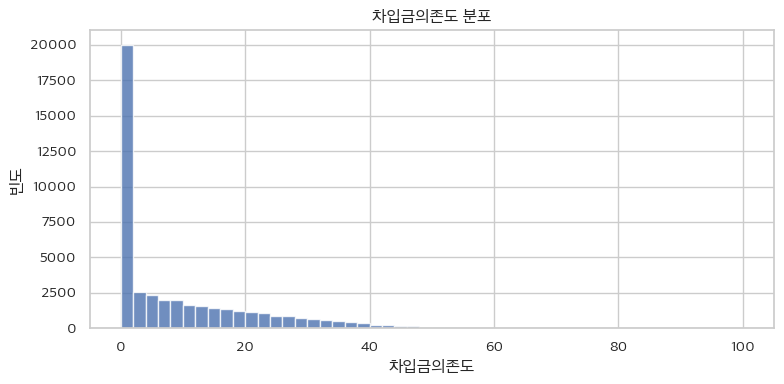

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


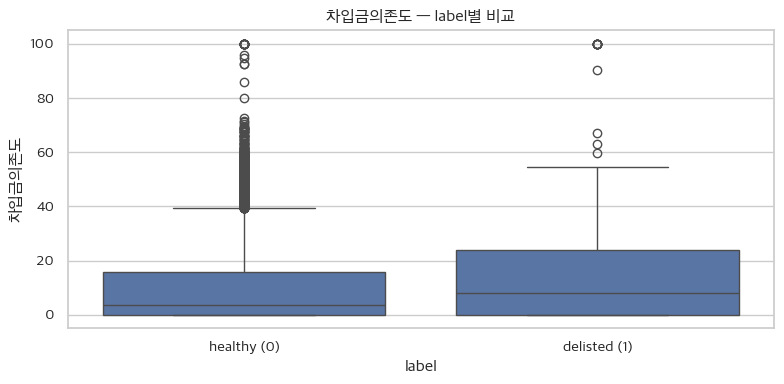


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,9.423716,3.682033,12.313201,0.0,100.0,0.0
1,154,17.600607,8.007293,25.200198,0.0,100.0,0.0



  매출총이익률
  count: 44503
  mean: 24.74137364740734
  median: 21.516419902497024
  std: 25.428673472647127
  min: -300.0
  max: 100.0
  q1: 12.222766296247848
  q3: 35.741793085574315
  iqr: 23.519026789326468
  skewness: -2.779685242773121
  kurtosis: 34.98857203826111


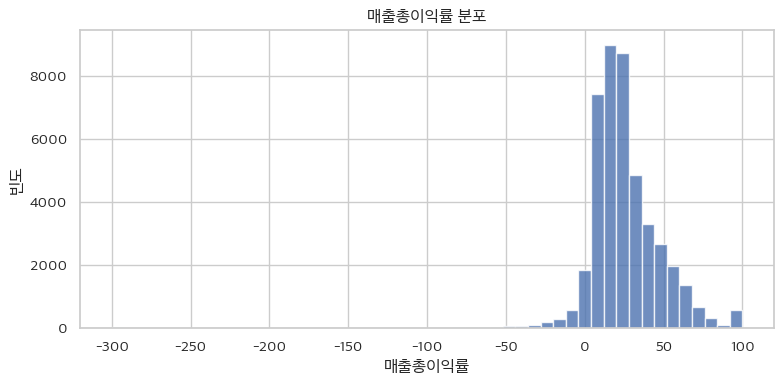

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


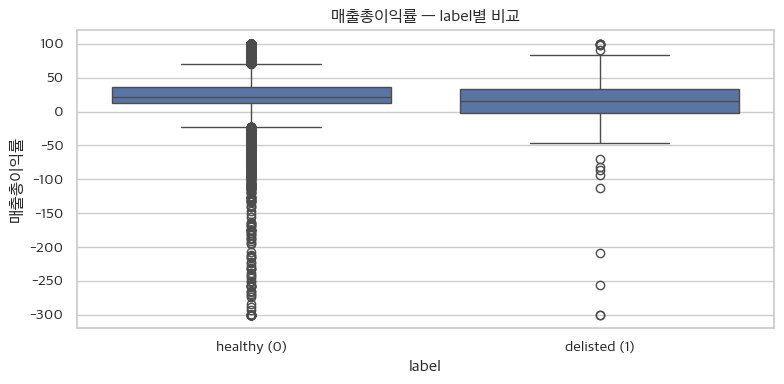


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,24.792807,21.516420,25.227640,-300.0,100.0,0.0
1,154,9.929632,15.802931,58.146749,-300.0,100.0,0.0



  현금비율
  count: 44503
  mean: 104.89903012915357
  median: 40.432589372653794
  std: 230.9164448137317
  min: 0.0
  max: 2000.0
  q1: 15.976412519634959
  q3: 97.08529085158713
  iqr: 81.10887833195217
  skewness: 5.815242264069339
  kurtosis: 40.143918549810145


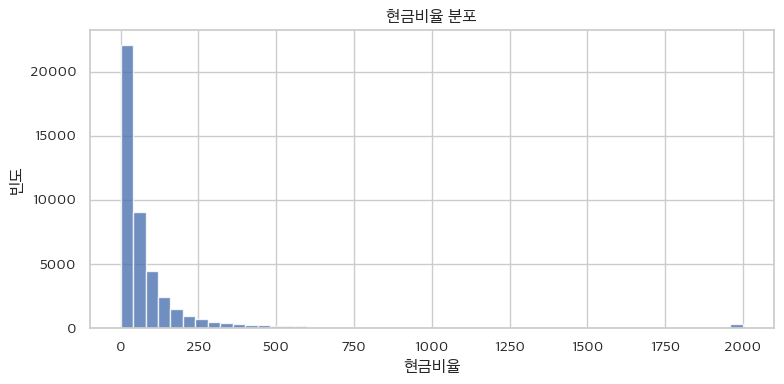

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


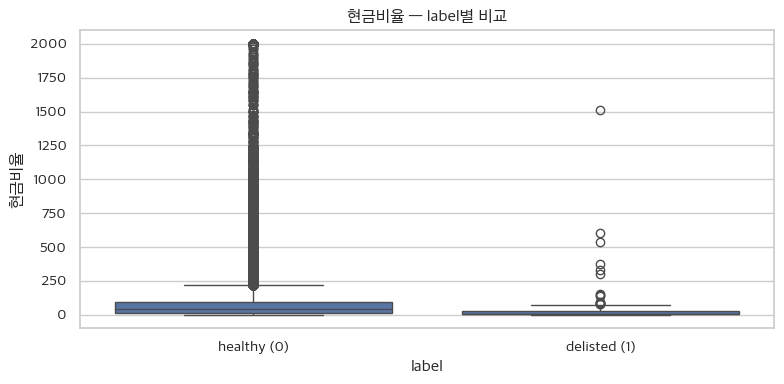


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,105.112715,40.560659,231.133683,0.000000,2000.000000,0.0
1,154,43.362060,7.599085,144.054893,0.000864,1511.144307,0.0



  credit_spread
  count: 44503
  mean: 0.6815919196458666
  median: 0.5906
  std: 0.2756410239572978
  min: 0.3758
  max: 1.5024
  q1: 0.4835
  q3: 0.7777
  iqr: 0.29419999999999996
  skewness: 1.5217789427660304
  kurtosis: 1.4728455565736


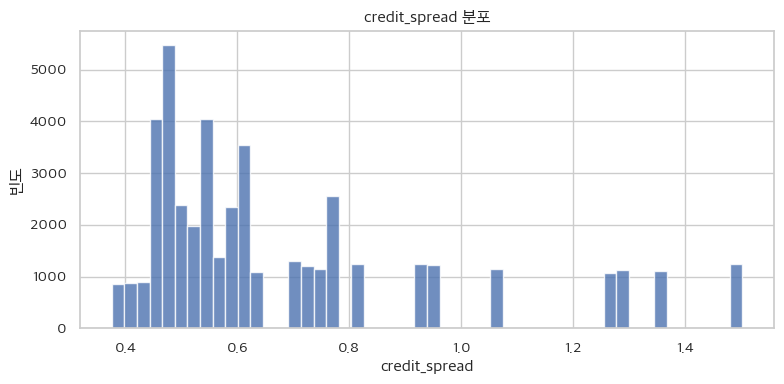

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


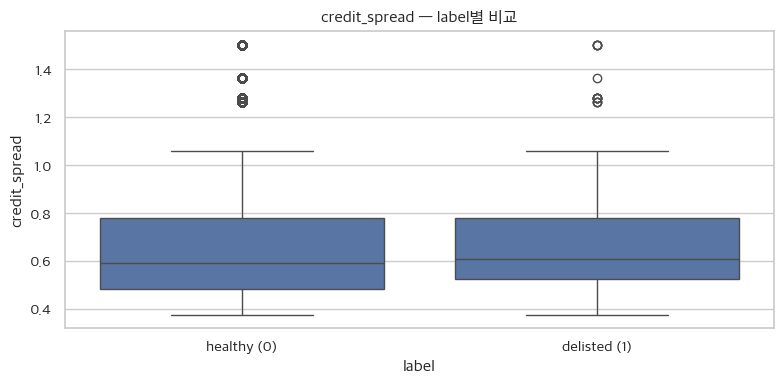


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,0.681506,0.5906,0.275676,0.3758,1.5024,0.0
1,154,0.706403,0.6076,0.264982,0.3758,1.5024,0.0



  kosdaq_return
  count: 44503
  mean: 1.1002216794373416
  median: 0.495
  std: 10.961722162835784
  min: -21.0782
  max: 29.68
  q1: -7.185
  q3: 7.7402
  iqr: 14.9252
  skewness: 0.4831089913833326
  kurtosis: 0.2041171299948732


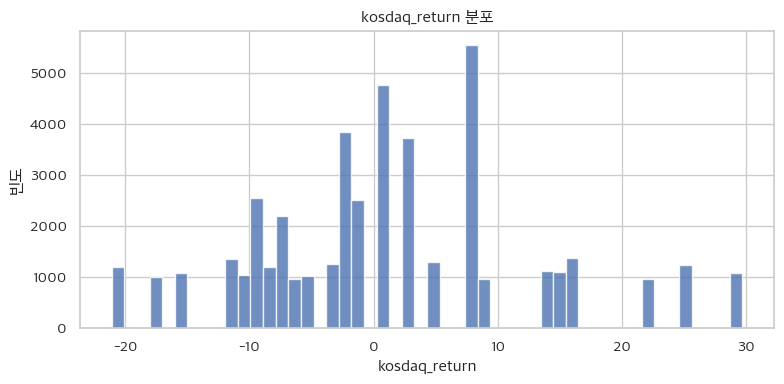

/Users/hann/Project/kwoss/kw0ss_project/src/analysis/utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["healthy (0)", "delisted (1)"])


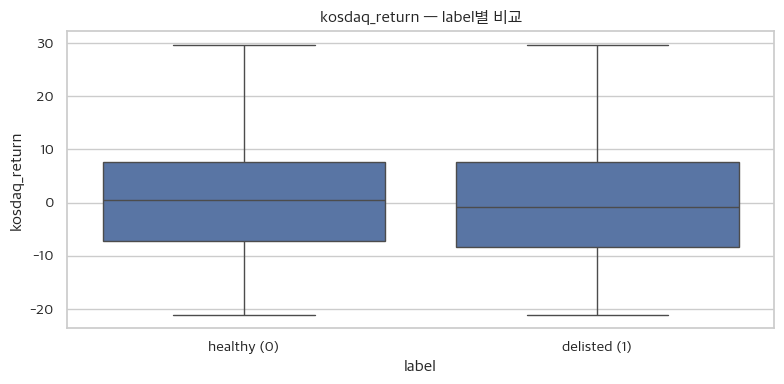


[Label별 비교]


,count,mean,median,std,min,max,null_pct
label,,,,,,,
0,44349,1.103150,0.4950,10.962299,-21.0782,29.68,0.0
1,154,0.257054,-0.7874,10.796460,-21.0782,29.68,0.0


In [16]:
for feat in TARGET_FEATURES:
    if feat not in df.columns:
        print(f"[SKIP] {feat} 없음")
        continue
    print(f"\n{'=' * 70}\n  {feat}\n{'=' * 70}")

    stats = analyze_single_feature(df, feat)
    for key, value in stats.items():
        print(f"  {key}: {value}")

    plot_histogram(df, feat)
    plot_boxplot_by_label(df, feat)

    print("\n[Label별 비교]")
    display(compare_group_stats_by_label(df, feat))


## 9. 상관관계 & 다중공선성 후보


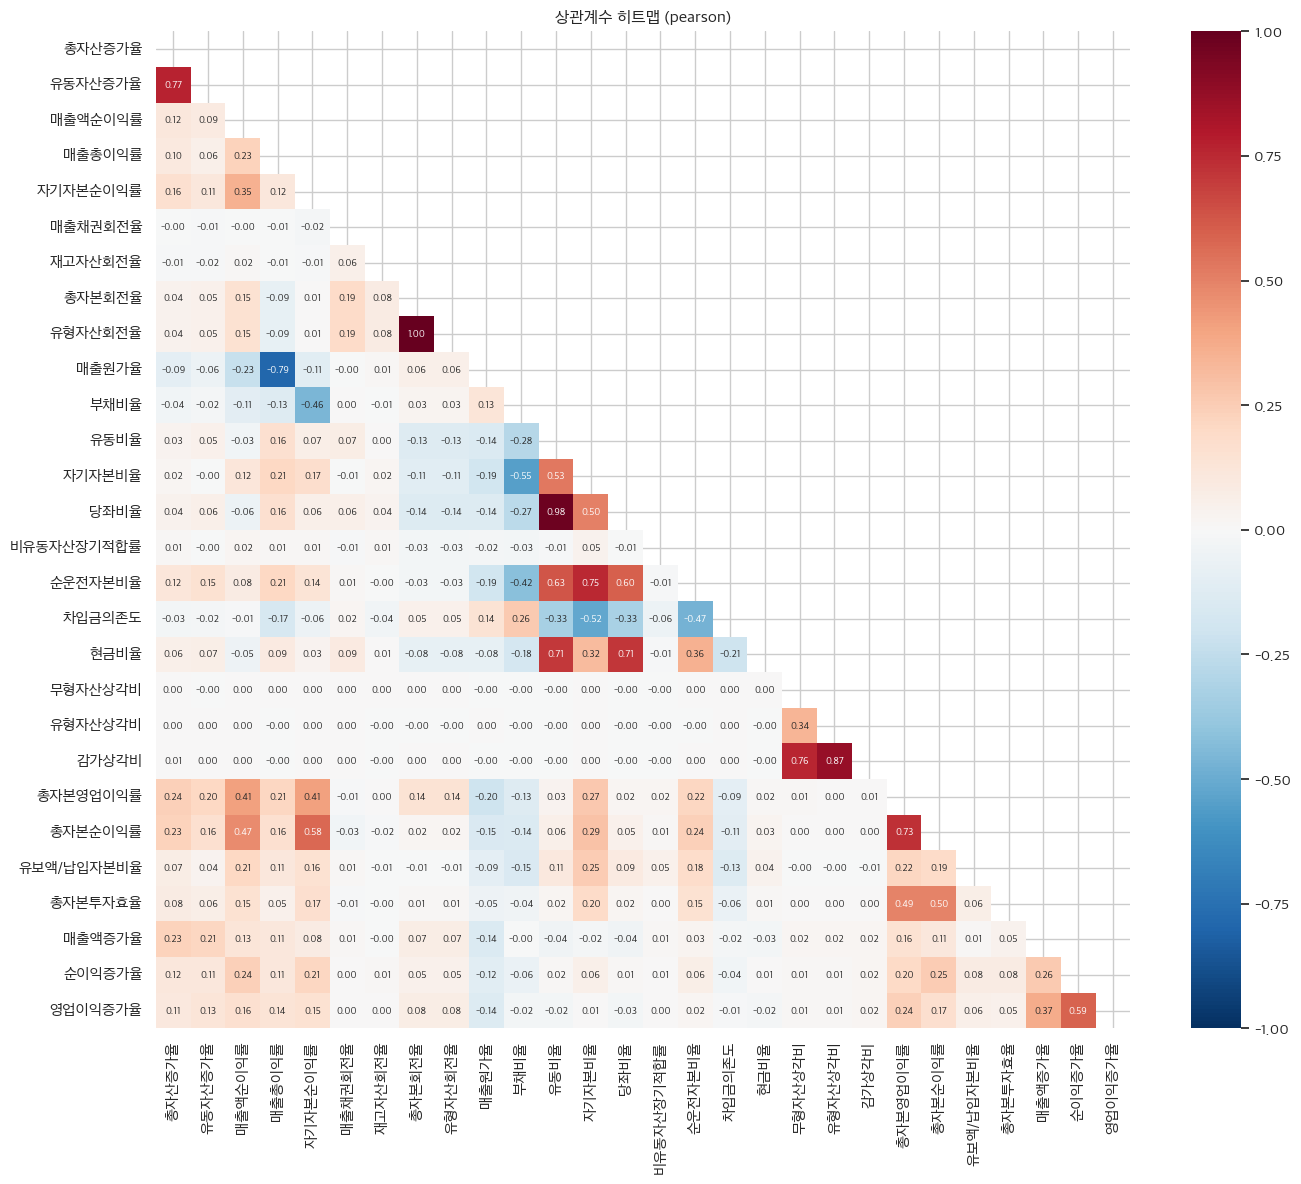

In [17]:
plot_correlation_heatmap(df.drop(columns=["split"]))


In [18]:
high_corr = get_high_corr_pairs(df.drop(columns=["split"]), threshold=0.8)
print(f"상관계수 절대값 ≥ 0.8 쌍: {len(high_corr)}개\n")
for col_a, col_b, corr_val in high_corr:
    print(f"  {col_a} <-> {col_b}: {corr_val}")

if high_corr:
    drop_candidates = set()
    for col_a, col_b, _ in high_corr:
        miss_a = df[col_a].isnull().mean()
        miss_b = df[col_b].isnull().mean()
        drop_candidates.add(col_a if miss_a >= miss_b else col_b)
    print(f"\n다중공선성 제거 후보 ({len(drop_candidates)}개): {sorted(drop_candidates)}")
else:
    print("다중공선성 후보 없음")


상관계수 절대값 ≥ 0.8 쌍: 3개

  총자본회전율 <-> 유형자산회전율: 1.0
  유동비율 <-> 당좌비율: 0.9792
  유형자산상각비 <-> 감가상각비: 0.8675

다중공선성 제거 후보 (3개): ['유동비율', '유형자산상각비', '총자본회전율']


## 10. Horizon별 품질 비교

모든 Hn/baseline에서 결측률, row 수, 라벨 비율이 어떻게 달라지는지 비교합니다.


In [19]:
quality_rows = []
for horizon in HORIZONS:
    split_map = get_horizon_data(horizon)
    for split_name, split_df in split_map.items():
        numeric_cols = split_df.select_dtypes(include="number").columns.tolist()
        feature_cols = [c for c in numeric_cols if c != "label"]
        quality_rows.append({
            "horizon": horizon,
            "split": split_name,
            "rows": len(split_df),
            "columns": len(split_df.columns),
            "positive": int(split_df["label"].sum()),
            "positive_rate_pct": split_df["label"].mean() * 100,
            "avg_feature_missing_pct": split_df[feature_cols].isna().mean().mean() * 100,
            "max_feature_missing_pct": split_df[feature_cols].isna().mean().max() * 100,
            "duplicate_key_rows": split_df.duplicated(["stock_code", "year", "quarter"]).sum(),
        })

quality_df = pd.DataFrame(quality_rows)
quality_df


Loading H8/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loading H10/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loading H12/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loading H14/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loading H16/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loading H18/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loading H20/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loading H22/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv
Loading H24/baseline ...
  - train: train.csv
  - valid: valid.csv
  - test: test.csv


,horizon,split,rows,columns,positive,positive_rate_pct,avg_feature_missing_pct,max_feature_missing_pct,duplicate_key_rows
0,6,train,34142,41,123,0.360260,0.0,0.0,0
1,6,valid,5050,41,11,0.217822,0.0,0.0,0
2,6,test,5311,41,20,0.376577,0.0,0.0,0
3,8,train,32746,41,167,0.509986,0.0,0.0,0
4,8,valid,5050,41,15,0.297030,0.0,0.0,0
5,8,test,5311,41,27,0.508379,0.0,0.0,0
6,10,train,31360,41,210,0.669643,0.0,0.0,0
7,10,valid,5050,41,21,0.415842,0.0,0.0,0
8,10,test,5311,41,36,0.677838,0.0,0.0,0
9,12,train,31360,41,250,0.797194,0.0,0.0,0


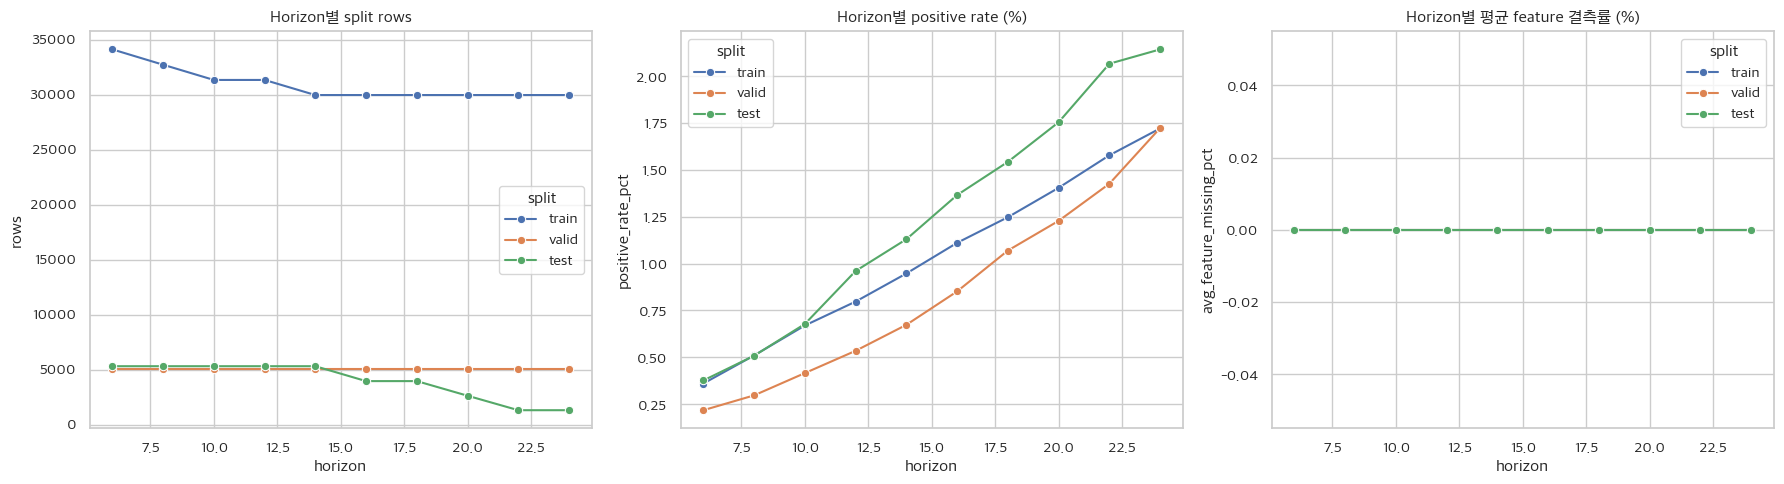

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=quality_df, x="horizon", y="rows", hue="split", marker="o", ax=axes[0])
axes[0].set_title("Horizon별 split rows")

sns.lineplot(data=quality_df, x="horizon", y="positive_rate_pct", hue="split", marker="o", ax=axes[1])
axes[1].set_title("Horizon별 positive rate (%)")

sns.lineplot(data=quality_df, x="horizon", y="avg_feature_missing_pct", hue="split", marker="o", ax=axes[2])
axes[2].set_title("Horizon별 평균 feature 결측률 (%)")

plt.tight_layout()
plt.show()


## 11. Split 누수/중복 점검

동일 `(stock_code, year, quarter)` 키가 train/valid/test 사이에 겹치는지 확인합니다.


In [21]:
leak_rows = []
key_cols = ["stock_code", "year", "quarter"]
for horizon in HORIZONS:
    split_map = get_horizon_data(horizon)
    key_sets = {
        split_name: set(map(tuple, split_df[key_cols].astype(str).to_numpy()))
        for split_name, split_df in split_map.items()
    }
    for left, right in [("train", "valid"), ("train", "test"), ("valid", "test")]:
        overlap = key_sets[left] & key_sets[right]
        leak_rows.append({
            "horizon": horizon,
            "pair": f"{left}-{right}",
            "overlap_keys": len(overlap),
        })

leak_df = pd.DataFrame(leak_rows)
leak_df.pivot(index="horizon", columns="pair", values="overlap_keys")


pair,train-test,train-valid,valid-test
horizon,,,
6,0,0,0
8,0,0,0
10,0,0,0
12,0,0,0
14,0,0,0
16,0,0,0
18,0,0,0
20,0,0,0
22,0,0,0


## 12. 간단 Baseline 모델 옵션

필요할 때 실행해 horizon별 Logistic Regression 성능을 빠르게 비교합니다. 클래스 불균형을 고려해 `class_weight='balanced'`를 사용합니다.


In [22]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

META_COLUMNS = {"stock_code", "year", "quarter", "gics_sector", "split"}
TARGET_COLUMN = "label"

def feature_columns(frame):
    return [c for c in frame.columns if c not in META_COLUMNS | {TARGET_COLUMN}]

model_rows = []
for horizon in HORIZONS:
    split_map = get_horizon_data(horizon)
    train_df = split_map["train"]
    valid_df = split_map["valid"]
    test_df = split_map["test"]
    features = feature_columns(train_df)

    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    )
    model.fit(train_df[features], train_df[TARGET_COLUMN])

    for split_name, eval_df in {"valid": valid_df, "test": test_df}.items():
        y_true = eval_df[TARGET_COLUMN]
        y_prob = model.predict_proba(eval_df[features])[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
        model_rows.append({
            "horizon": horizon,
            "split": split_name,
            "roc_auc": roc_auc_score(y_true, y_prob) if y_true.nunique() > 1 else None,
            "pr_auc": average_precision_score(y_true, y_prob),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "positive": int(y_true.sum()),
        })

model_df = pd.DataFrame(model_rows)
model_df


,horizon,split,roc_auc,pr_auc,precision,recall,f1,positive
0,6,valid,0.882210,0.100111,0.008475,0.818182,0.016775,11
1,6,test,0.851011,0.111421,0.012556,0.700000,0.024670,20
2,8,valid,0.899874,0.145220,0.012416,0.866667,0.024482,15
3,8,test,0.858230,0.131819,0.021645,0.740741,0.042061,27
4,10,valid,0.877955,0.089942,0.014717,0.904762,0.028963,21
5,10,test,0.872928,0.136868,0.023831,0.750000,0.046193,36
6,12,valid,0.894773,0.137234,0.020781,0.925926,0.040650,27
7,12,test,0.877943,0.197594,0.035587,0.784314,0.068085,51
8,14,valid,0.899574,0.108344,0.032548,0.852941,0.062703,34
9,14,test,0.830140,0.122188,0.041451,0.666667,0.078049,60


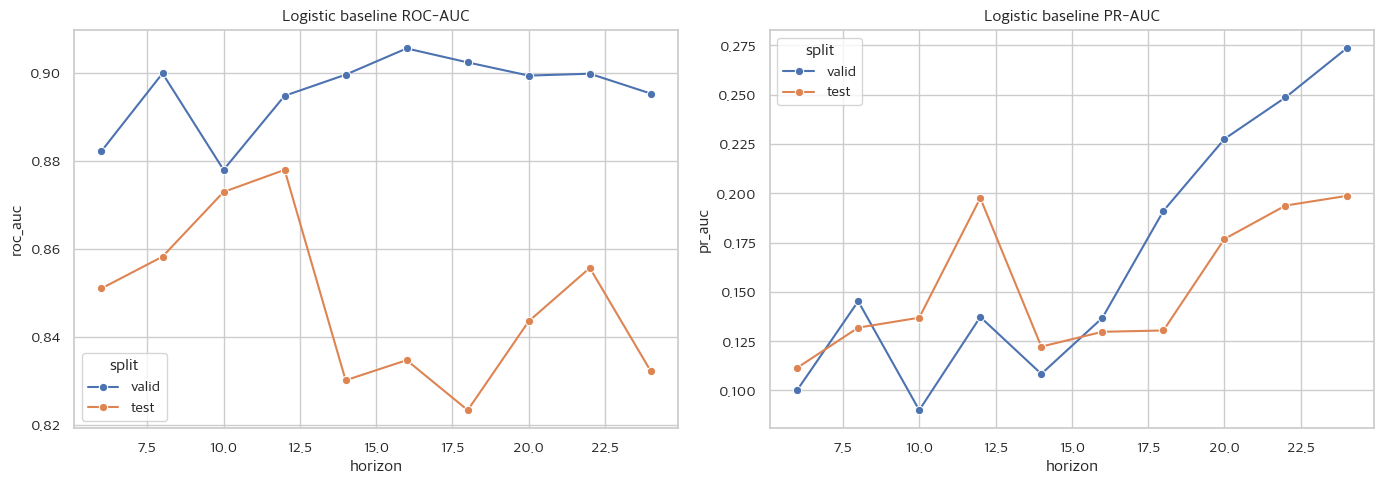

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=model_df, x="horizon", y="roc_auc", hue="split", marker="o", ax=axes[0])
axes[0].set_title("Logistic baseline ROC-AUC")
sns.lineplot(data=model_df, x="horizon", y="pr_auc", hue="split", marker="o", ax=axes[1])
axes[1].set_title("Logistic baseline PR-AUC")
plt.tight_layout()
plt.show()
